In [ ]:
import pandas as pd

cols = [
    "id", "t0", "tc", "mz1", "mz2",
    "s1", "s1x", "s1y", "s1z",
    "s2", "s2x", "s2y", "s2z",
    "lambda1", "lambda2",
    "z", "distMpc",
    "ra", "decl",
    "psi", "inc", "phi0",
    "snrET_Opt", "snrCE_Opt",
    "type"
]

df = pd.read_csv("list_mdc1.txt", delim_whitespace=True, names=cols)

bbh_df = df[df["type"] == 3]


# Optional: save result
bbh_df.to_csv("bbh_parameters.txt", sep=" ", index=False)

print(bbh_df.head())

/tmp/ipykernel_17537/3297061749.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("list_mdc1.txt", delim_whitespace=True, names=cols)


Empty DataFrame
Columns: [id, t0, tc, mz1, mz2, s1, s1x, s1y, s1z, s2, s2x, s2y, s2z, lambda1, lambda2, z, distMpc, ra, decl, psi, inc, phi0, snrET_Opt, snrCE_Opt, type]
Index: []

[0 rows x 25 columns]


/tmp/ipykernel_17537/3297061749.py:15: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("list_mdc1.txt", delim_whitespace=True, names=cols)


In [9]:
import pandas as pd

# Load file
df = pd.read_csv("list_mdc1.txt", delim_whitespace=True)

# Filter BBHs
bbh_df = df[df["type"] == 3]

# Select only the mass columns
bbh_masses = df[df["type"] == 3][["mz1", "mz2"]]
# Remove decimals by truncation
bbh_masses = bbh_masses.astype(int)

# save result
bbh_df.to_csv("bbh1_parameters.txt", sep=" ", index=False)
bbh_masses.to_csv("bbh1_masses.txt", sep=" ", index=False)


/tmp/ipykernel_22527/41944712.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("list_mdc1.txt", delim_whitespace=True)


In [10]:
import pandas as pd

df = pd.read_csv("list_mdc1.txt", delim_whitespace=True)

# Filter BBHs
df = df[df["type"] == 3]

df["m1_source"] = df["mz1"] / (1 + df["z"])
df["m1_source"] = df["m1_source"].astype(int)
df["m2_source"] = df["mz2"] / (1 + df["z"])
df["m2_source"] = df["m2_source"].astype(int)

df[["m1_source", "m2_source"]].to_csv(
    "bbh_masses_source.txt", sep=" ", index=False
)

/tmp/ipykernel_22527/2223503669.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("list_mdc1.txt", delim_whitespace=True)


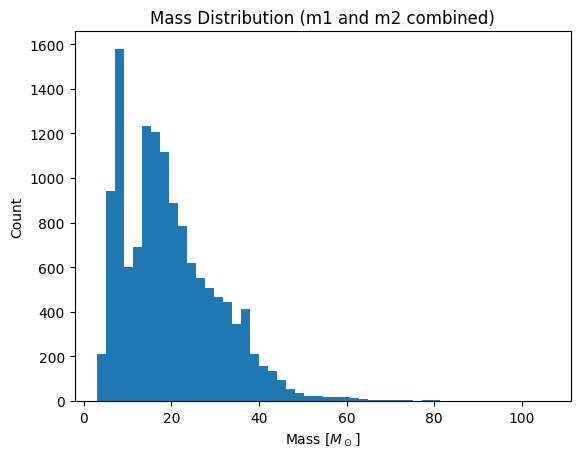

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Load your file
data = np.loadtxt("bbh_masses_source.txt", skiprows=1)

m1 = data[:, 0]
m2 = data[:, 1]

# Combine both masses
masses = np.concatenate([m1, m2])

plt.figure()
plt.hist(masses, bins=50)
plt.xlabel("Mass [$M_\\odot$]")
plt.ylabel("Count")
plt.title("Mass Distribution (m1 and m2 combined)")
plt.show()

In [15]:
import numpy as np

data = np.loadtxt("bbh_masses_source.txt", skiprows=1)

m1 = data[:, 0]
m2 = data[:, 1]

# Combine all component masses
masses = np.concatenate([m1, m2])

# Compute percentiles
p1 = np.percentile(masses, 1)
p10 = np.percentile(masses, 10)
p20 = np.percentile(masses, 20)
p50 = np.percentile(masses, 50)  # Median
p80 = np.percentile(masses, 80)
p90 = np.percentile(masses, 90)
p99 = np.percentile(masses, 99)
p999 = np.percentile(masses, 99.9)
p9999 = np.percentile(masses, 99.99)

print("1% mass:", p1)
print("10% mass:", p10)
print("20% mass:", p20)
print("50% mass:", p50)
print("80% mass:", p80)
print("90% mass:", p90)
print("99% mass:", p99)
print("99.9% mass:", p999)
print("99.99% mass:", p9999)

1% mass: 5.0
10% mass: 8.0
20% mass: 9.0
50% mass: 18.0
80% mass: 29.0
90% mass: 35.0
99% mass: 53.0
99.9% mass: 79.0
99.99% mass: 97.96529999999439
